# Firmware Release 1.5.6 Changes walkthrough

This notebook describes API and functional changes in the R1.5.6 firmware release.

1.5.6 - 2025-07-02

## Implements much faster data rates over the 1G Ethernet line

**API Changes**
- `crs.set_fir_stage()/crs.get_fir_stage()` is now `crs.set_decimation()/crs.get_decimation()`
   - Since there's no FIR anywhere in the system, the old function name was nothing but confusing.
     The new call can now also stream channel and module subsets to increase the available network bandwidth for high-rate modules.
- `set_decimation()` has a new variety of arguments. In order to get all the way to the lowest decimation stages (fastest streaming) it is necessary to filter the streamed data so only a subset of the channels is emitted. This is done in two ways: by selecting subsets of modules to stream, and by selecting subsets of channels within the modules to stream.
   - The "SHORT" packetizer is required for the lowest decimation stages, and will only stream the first 128 channels of the selected module(s).
     

**Bug Fixes**
- Fixes the IRIG-B encoder/decoder. Timestamps previously rolled over faster than
  they should have. The IRIG-B TEST-mode encoder and decoder both had this bug, and therefore were self-consistent.
  However, anybody using a true IRIG-B source would have noticed a second was slightly off.
  
**Improvements (likely invisible)**
- Kernel-mode streamer support is now multi-core to keep up with faster
  sampling rates. Using these new features:
```python
await crs.set_decimation(0, short=True, modules=[1])
```
  will stream packets at the lowest decimation (stage 0, 38.147 ksps) without packet loss.
- `get_samples()`, `py_get_samples`, and the `parser` have all been updated to be able to re-arrange slightly out of order packets, which can now happen due to the multi-core packetizer on the ARM to service the higher streaming rates.

----


In [1]:
%matplotlib widget
# NB: suggest using %matplotlib widget instead of inline when not running locally on the CRS

import numpy as np
import matplotlib.pylab as plt
import time

import rfmux
s = rfmux.load_session('!HardwareMap [ !CRS { serial: "0020" } ]') # Replace with your board serial
crs = s.query(rfmux.CRS).one()                                     # Loads a CRS object
await crs.resolve()                                                # Loads all of the methods and docstrings into python
await crs.set_timestamp_port(crs.TIMESTAMP_PORT.TEST)              # Lab use with internal timestamps

Set the new decimation stages using `crs.set_decimation`

- the `module` argument can be an int (1), or a list [1,2].
- the `short` argument will toggle whether only the first 128 channels are streamed
- If you request a streaming amount that is too high, it will throw an exception
- If you `get_samples` from a module that is being filtered, it will throw an exception

In [8]:
crs.set_decimation?

Signature: crs.set_decimation(*args, **kwargs)
Docstring:
set_decimation(self: libmkids.Dfmux, stage: int = 6, short: bool = False, module: Union[None, int, List[int]] = None) -> None:

Set the decimation rate and configure which modules are streamed.

The output sampling rate is related to the "stage" parameter
as follows:

        sampling_rate = 625e6 / 256 / 64 / 2**stage

Stage values between 1 and 6 are legal.

The "module" parameter determines which modules are
streamed. By default (value None), all modules are
streamed.  You can reduce network traffic by specifying
either a single module (an integer argument, in which
case all other modules are not streamed), or a list of
modules to stream.
File:      ~/code/rfmux/rfmux/tuber/client.py
Type:      method

In [3]:
crs.set_decimation(0,module=[1,2])

TuberRemoteError: RuntimeError: This combination of set_decimation arguments would produce 5 Gbps, which is beyond the carrying capacity of the 1 GbE link.

In [25]:
crs.set_decimation(3,module=[1,2])
dec_stage = await crs.get_decimation()
print("Decimation Stage is {}, {} Hz".format(dec_stage, rfmux.core.transferfunctions.decimation_to_sampling(dec_stage)))
crs.get_samples(10,module=3) # Won't work

Decimation Stage is 3, 4768.37158203125 Hz


TuberRemoteError: RuntimeError: This module is not currently streamed! Refusing to wait forever for samples that won't arrive.

# Firmware Release 1.5.4 Changes walkthrough

This notebook describes API and functional changes in the R1.5 firmware release.

1.5.4 - 2025-01-13

This is a "big" release - we are going to try and re-instate a small,
incremental release cadence. More frequent releases tend to be smoother.

**API Changes**
- API modifications - Units gone for:
    - `get_fast_samples/get_pfb_samples`
    - `set_nco_frequency/get_nco_frequency`
    - `set_frequency/get_frequency`
    - `set_amplitude/get_amplitude`
- `get_pfb_samples` returns i/q lists rather than (i, q) tuples -- standarized with get_samples
- Automatic higher-nyquist adjustment (set frequencies in intuitive ways)
- API now uses modules 1-8, with `set_analog_bank` selecting which half is valid
- TARGET parameters are now fully rational (DAC and ADC are the only two that are valid)

**New Features**
- Q-control and q-norm present in firmware
- "average" mode added to `get_samples`, `get_pfb_samples`, `get_fast_samples`
- "spectra" mode added to `py_get_samples`, `py_get_pfb_samples`
- Different ton maintain consistency in absolute phase -- no more rerouted or "cal" samples required
- `take_netanal` as an algorithm is now baked into rfmux (see `rfmux/docs...`)

**Improvements (likely invisible)**
- NCO and associated functions now configure RFDC compensation
  settings (DAC pulse shaping; inverse-sinc compensation)
    - Corrects for the passband shape in first two nyquist regimes
- ADC dither enabled on power-up
    - Much better noise performance when in the low signal regime of operating only a few channels
- `get_samples()` includes contiguity check
- LO uses 32-bit phase accumulator again (smaller frequency resolution)
- Overrange/overvoltage errors are no longer sticky
- Sporadic failures in get_pfb_samples fixed. These errors propagated an
  exception upwards (so they were visible when they occurred) - if you didn't
  notice, this fix is not interesting.
- Parser is statically linked and hence more portable
- ssh fixed (private keys were chmod'd permissively enough that sshd refused to
  start)

----


## API Changes

These changes will break compatibility with software.
The goal is to iteratively move the API towards increasing simplicity, and retiring backwards compatibility with previous hardware systems, as that compatibility layer is moved into software.

In [1]:
%matplotlib widget
# NB: suggest using %matplotlib widget instead of inline when not running locally on the CRS

import numpy as np
import matplotlib.pylab as plt
import time

import rfmux
s = rfmux.load_session('!HardwareMap [ !CRS { serial: "0022" } ]') # Replace with your board serial
crs = s.query(rfmux.CRS).one()                                     # Loads a CRS object
await crs.resolve()                                                # Loads all of the methods and docstrings into python
await crs.set_timestamp_port(crs.TIMESTAMP_PORT.TEST)              # Lab use with internal timestamps

### 1. Simplified arguments for get/set frequency, amplitude, and sample captures

In [2]:
crs.ra

AttributeError: 'Dfmux' has no attribute 'raise_periscope'.  Did you run tuber_resolve()?

In [2]:
crs.set_frequency(100e6,channel=1, module=3)   # No longer requires UNITS argument (assumed Hz)
crs.get_frequency(channel=1, module=3)         # No longer requires UNITS argument (assumed Hz)
crs.set_nco_frequency(1e9, module=3)           # No longer requires UNITS argument (assumed Hz)
crs.get_nco_frequency(module=3)                # No longer requires UNITS argument (assumed Hz)

crs.set_amplitude(0.01,channel=1,module=3)    # No longer requires UNITS or TARGET arguments (Assumed Normalized and DAC)
crs.get_fast_samples(1000, module=3)          # No longer requires UNITS (assumed normalized to ADC dynamic range)
crs.get_pfb_samples(1000,channel=1, module=3) # No longer requires UNITS argument (now the same units as get_samples)

<Task finished name='Task-22' coro=<TuberObject._resolve_method.<locals>.invoke() done, defined at /home/joshua/code/rfmux/rfmux/tuber/client.py:691> result={'i': [-15086..., 4823, 4814]}>

### 2. All get_*_samples calls return the same structure

Previously get_samples returned a struct with lists for I and Q, but get_pfb_samples returned tuples that had to be unpacked.
All of these calls now have the same unified output structure:

In [3]:
samples = await crs.get_pfb_samples(5,channel=1, module=3)
print(samples)
print(samples.i)
print(samples.q)

{'i': [-15064, -15073, -15107, -15161, -15222], 'q': [4752, 4803, 4843, 4851, 4836]}
[-15064, -15073, -15107, -15161, -15222]
[4752, 4803, 4843, 4851, 4836]


### 3. Automatic higher-nyquist adjustment (set frequencies in intuitive ways)

**Set frequencies in any Nyquist region directly with `set_nco_frequency` and `set_frequency`.**

Previously you had to do your own math to calculate the digital frequencies to set in order to generate higher-nyquist tones, and also you had to tell the system which nyquist zone you intended to use in order to set the optimal DAC mode.

Now, all of this happens automatically. By setting the NCO to 2.8GHz, the system will automatically switch DAC and ADC modes to be optimal for that nyquist region and will ensure subsequent `set_frequency` calls behave appropriately. It will also adjust the inverse sinc filter to compensate for the digital attenuation. Thus `set_frequency(100e6)` will produce a tone at 2.9GHz and the resulting passband will be flat with respect to the digital sinc response.

In the example below, we scan through the first two nyquist regions using:

* **MODULE 1 cable loopback:** Nyquist Region 1 Filter Stack: 2x VLFG-2000+ (Minicircuits)
* **MODULE 2 cable loopback:** Nyquist Region 2 Filter Stack: 2x VHF-2700A+ and 2x VLF-3800+ (Minicircuits)

This is a conservative filter stack, sacrificing some passband for strong attenuation of aliases.
Sharper filters are possible using more expensive off-the-shelf options, or custom microstrip options (t0 versions in development).

<div class="alert alert-block alert-danger"> The minicircuits filter stacks use impedance mismatching to control the passband. So long stacks of different filters (like above) can have unexpected behavior. Be sure these are always stacked together, and with like-filters together. Use cables that are sufficiently long that the nulls are not in-band (1M-ish). Reflectionless filters or a single custom microstrip filter are better.</div>

<div class="alert alert-block alert-warning"> Automatic compensation and optimal DAC mode switching is not yet implemented for Nyquist Zone 3 and 4. Frequencies from 5-10GHz can still be generated using the same syntax, but the passband will not be automatically flattened. This is pending the next release. </div>

#### Example network analysis with two nyquist regions
This is an inefficient way to take this measurement, taken by sweeping just the NCO with a single channel, but written as such for simplicity


In [8]:
crs.clear_channels()

amps = []
freqs = np.linspace(0.01e9, 2.49e9, 500)
crs.set_frequency(1e6, channel=1, module=3)
crs.set_amplitude(0.1, channel=1, module=3)
for f in freqs:
    crs.set_nco_frequency(f, module=3)
    samples = await crs.get_samples(10, average=True, channel=1, module=3)
    amps.append(np.abs(samples.mean.i+1j*samples.mean.q))

amps_2nd = []
freqs_2nd = np.linspace(2.501e9,4.99e9,500)
crs.set_frequency(1e6, channel=1, module=4)
crs.set_amplitude(0.1, channel=1, module=4)
for f in freqs_2nd:
    crs.set_nco_frequency(f, module=4)
    samples = await crs.get_samples(10, average=True, channel=1, module=4)
    amps_2nd.append(np.abs(samples.mean.i+1j*samples.mean.q))

In [4]:
crs.clear_channels()

amps = []
freqs = np.linspace(0.01e9, 2.499e9, 500)
crs.set_frequency(1e6, channel=1, module=3)
crs.set_amplitude(0.1, channel=1, module=3)
for f in freqs:
    crs.set_nco_frequency(f, module=3)
    samples = await crs.get_samples(10, average=True, channel=1, module=3)
    amps.append(np.abs(samples.mean.i+1j*samples.mean.q))

amps_2nd = []
freqs_2nd = np.linspace(0.01e9, 2.499e9, 500)
crs.set_frequency(1e6, channel=1, module=4)
crs.set_amplitude(0.1, channel=1, module=4)
for f in freqs_2nd:
    crs.set_nco_frequency(f, module=4)
    samples = await crs.get_samples(10, average=True, channel=1, module=4)
    amps_2nd.append(np.abs(samples.mean.i+1j*samples.mean.q))

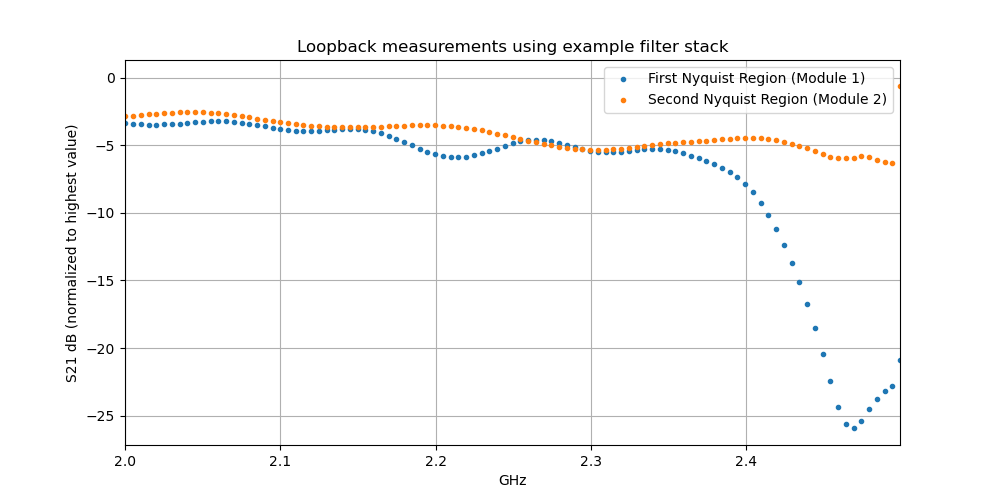

In [12]:
%matplotlib widget
plt.figure(figsize=(10,5))

ref_amp = max(amps)

plt.plot(np.array(freqs)/1e9, 20 * np.log10(np.abs(amps/ref_amp)),'.', label='First Nyquist Region (Module 1)')
plt.plot(np.array(freqs_2nd)/1e9, 20 * np.log10(np.abs(amps_2nd/ref_amp)), '.', label='Second Nyquist Region (Module 2)')

# ax = plt.gca()  # Get the current axes
# ax.set_xticks([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.xlim(2,2.499)
plt.xlabel("GHz")
plt.ylabel("S21 dB (normalized to highest value)")
plt.title("Loopback measurements using example filter stack")
plt.legend()
plt.grid()

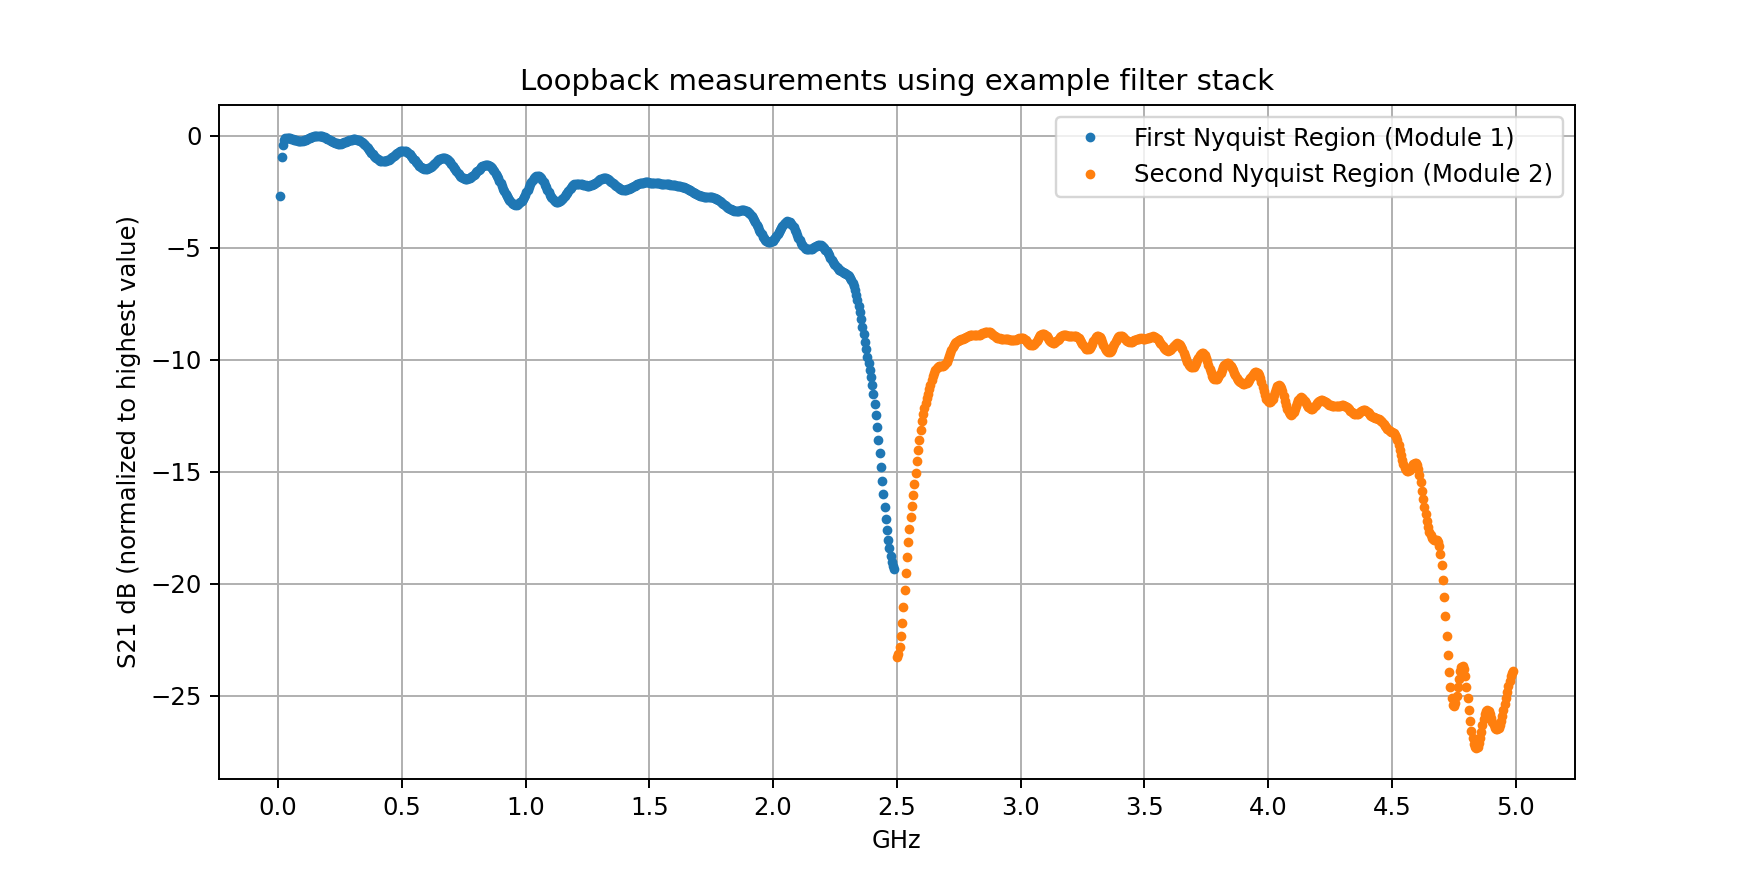


In this figure, the dips near 2.5GHz and roll-off near 5GHz is due to the transition bands of the minicircuits filters. Sharper filters will recover more of the useable bandwidth. The ~12dB round-trip analog loss over 5GHz reconstructs the analog DAC performance now that the sinc filter artifacts are compensated for automatically.

### 4. API now uses modules 1-8. `set_analog_bank` is used to select which set is used

The CRS has 8 separate modules, each module is an ADC/DAC pair. However, only four of these can be active at a time.
The method `set_analog_bank` is used to switch between the lower 4 active or the upper 4.

```python
>>> crs.set_analog_bank?

Signature: crs.set_analog_bank(*args, **kwargs)
Docstring:
set_analog_bank(self: libmkids.Dfmux, high: bool = False) -> None:

Configure analog-bank multiplexing to "high" or "low" mode.

The CRS board has 8 ADCs and 8 DACs, and firmware
currently only supports 4 readout modules. To allow the
other 4 converters to be used, this function selects
whether the first (high=False) or second (high=True)
converters are used.
File:      ~/code/rfmux/rfmux/tuber/client.py
Type:      method

```


<div class="alert alert-block alert-info">
<b>Note:</b> You can now check the docstrings and arguments of any method as above by adding "?" (eg crs.set_analog_bank?)
</div>

**All methods that accept modules can now use modules 1-8, and hardware maps can assign channels to all 8 modules.**

Methods will throw an exception if you try to operate on a module when the analog bank is set incorrectly:

In [6]:
await crs.set_frequency(100e6,channel=1,module=8)

TuberRemoteError: ValueError: Can't access module 8 with low analog banking!

In [7]:
crs.set_analog_bank(high=True)
await crs.set_frequency(100e6, channel=1, module=8)

In [8]:
crs.modules.all()

[CRS(0022).ReadoutModule(1),
 CRS(0022).ReadoutModule(2),
 CRS(0022).ReadoutModule(3),
 CRS(0022).ReadoutModule(4),
 CRS(0022).ReadoutModule(5),
 CRS(0022).ReadoutModule(6),
 CRS(0022).ReadoutModule(7),
 CRS(0022).ReadoutModule(8)]

<div class="alert alert-block alert-warning">
<b>WARNING:</b> Code that iterates blindly over crs.modules will throw an exception if the analog bank isn't adjusted between modules 1-4 and 5-8. Any asynchronous function call must operate on objects in EITHER modules 1-4 OR modules 5-8, but not a combination.
</div>

To gather subsets of modules to iterate over, filter the Readout Module results:

```python
rmods_low = crs.modules.filter(rfmux.ReadoutModule.module.in_([1,2,3,4]))
rmods_high = crs.modules.filter(rfmux.ReadoutModule.module.in_([5,6,7,8]))
```

You can then run asynchronous operations on one of those collections and then the other one.

This is a little clunky, but is the next step on the road to 8 full modules, eliminating the high and low bank API

------

## New Features


### 1. Q-control and Q-norm present in firmware

These feedback modes allow the resonator to be fixed in frequency by varying the readout power.
Initial testing has been successful, but this is still an experimental feedback mode, and we are still developing best practices.

If you are interested in experimenting with them, write to Joshua and Maclean, we can help get you set up.
They will be more completely documented with a companion paper on the subsequent release.

### 2. "average" mode added to all `get_*_samples` routines

These functions now return statistics such as the mean and standard deviation for the I and Q values independently, as well as flags for whether the input was railed (overrange or overvoltage). This is also available for `py_get_samples`.



In [9]:
crs.get_samples?

Signature: crs.get_samples(*args, **kwargs)
Docstring:
get_samples(self: libmkids.Dfmux, num_samples: int, average: bool = False, channel: Optional[int] = None, module: int) -> dict:

Retrieve samples from the readout signal path.

If 'average' is specified, returns statistics only
(mean and standard deviation) and not the underlying
samples. Using 'average' can speed up the function
call, because large arrays of numerical values do not
need to be serialized on the CRS and deserialized on
your PC.

If 'channel' is specified, returns values for only a
single channel. Otherwise, all 1024 channels in the
specified module are returned.
File:      ~/code/rfmux/rfmux/tuber/client.py
Type:      method

In [10]:
samples = await crs.get_samples(100, average=True, channel=1, module=5)
print("Full structure:", samples)
print("Mean:", samples.mean)
print("Mean of i:", samples.mean.i)

Full structure: {'mean': {'i': -67.021015625, 'q': -64.1293359375}, 'std': {'i': 2.4717084343076516, 'q': 2.5891621519535994}, 'flags': {'overrange': False, 'overvoltage': False}}
Mean: {'i': -67.021015625, 'q': -64.1293359375}
Mean of i: -67.021015625


In [11]:
a=time.time();crs.get_samples(10, average=True, module=5);b=time.time()
print("When averaging 10 samples: {0:.4f} Seconds".format(b-a))

a=time.time();crs.get_samples(10, average=False, module=5);b=time.time()
print("When collecting 10 samples {0:.4f} Seconds".format(b-a))

When averaging 10 samples: 0.0355 Seconds
When collecting 10 samples 0.3697 Seconds


### 3. `py_get_samples` and `py_get_pfb_samples` can now return spectra.

See `rfmux/docs/demos/Noise Spectra.ipynb` for a detailed description and usage.
These functions now optionally return full spectra in dBm/Hz or dBc/Hz.

See `crs.py_get_samples?` and `crs.py_get_pfb_samples?` for arguments and usage.


### 4. Absolute phase measurements are automatically compensated for

In order to reconstruct absolute phase vs frequencies, it used to be necessary to take "internally rerouted" samples, and compensate first for the internal phase shifts, and then for a large effective latency.

This is now done automatically, such that the only phase shift you should see is from the physical cable delays between the SMAs.
This can also be approximately compensated for automatically by calling `await crs.set_cable_length(length=0.28, module=1)` with the length in meters.

A complete network analysis algorithm is now built into rfmux, including asynchronous operation:

```python
results = await crs.take_netanal(module=1)     # This will execute a network analysis on module 1
results = await crs.take_netanal(module=[1,3]) # This will execute a network analysis on modules 1 and 3 asychronously
```

For asynchronous operation on multiple boards, or with different arguments for each module, use the following paradigm:
```python
for m in modules: # where modules is a hardware map query object with many modules
    tasks.append(m.crs.take_netanal(
        amp=amp,             # default: 0.001
        fmin=fmin,           # default 100 MHz
        fmax=fmax,           # default 2.45 GHz
        nsamps=nsamps,       # default 10
        npoints=npoints,     # default 5000
        max_chans=max_chans, # default 1023
        max_span=max_span,   # default 500 MHz
        module=m.module,     # the module number, or list of module numbers
    ))
results = await asyncio.gather(*tasks)
return results
```
Consult the `crs.take_netanal?` docstring for more detailed arguments and `rfmux/algorithms/measurement/take_netanal.py` for best-practices in making your own network analysis code.

<div class="alert alert-block alert-info">
<b>Note:</b> Asynchronous speedups when using a single board are currently marginal. This is most powerful when using modules on multiple boards. However, there are a few different ways we see to speed this up, and so this will improve for single-board operation in the future.
</div>

In [12]:
crs.set_analog_bank(high=False) # Move back to the lower bank to use modules 1 and 2

crs.clear_channels()
crs.set_cable_length(length=0.28, module=1)  # Additional phase correction for cable latencies (note: approximate)
crs.set_cable_length(length=1.825, module=3) # Additional phase correction for cable latencies (note: approximate)
a=time.time()
modules = [1,3]
results = await crs.take_netanal(amp=0.001, fmin=50e6, fmax=2.5e9, nsamps=500, 
                                 npoints=5000, max_chans=1023, module=modules)
print(time.time()-a)

11.395439863204956


In [ ]:
fig, axes = plt.subplots(1, len(results), figsize=(10, 4))

for i, result in enumerate(results):
    fs, mean_iq, mean_phase = result
    
    ax1 = axes[i]
    color_mag = 'tab:blue'
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Magnitude', color=color_mag)
    ax1.plot(fs, np.abs(mean_iq), '.-', color=color_mag)
    ax1.tick_params(axis='y', labelcolor=color_mag)
    ax1.set_ylim(0, 2000)
    ax1.grid(True)
    
    ax2 = ax1.twinx()
    color_phase = 'tab:red'
    ax2.set_ylabel('Phase (deg)', color=color_phase)
    ax2.plot(fs, np.unwrap(mean_phase, period=180), '.', color=color_phase)
    ax2.tick_params(axis='y', labelcolor=color_phase)
    ax1.set_title(f"Module {modules[i]}")

plt.tight_layout()
plt.show()


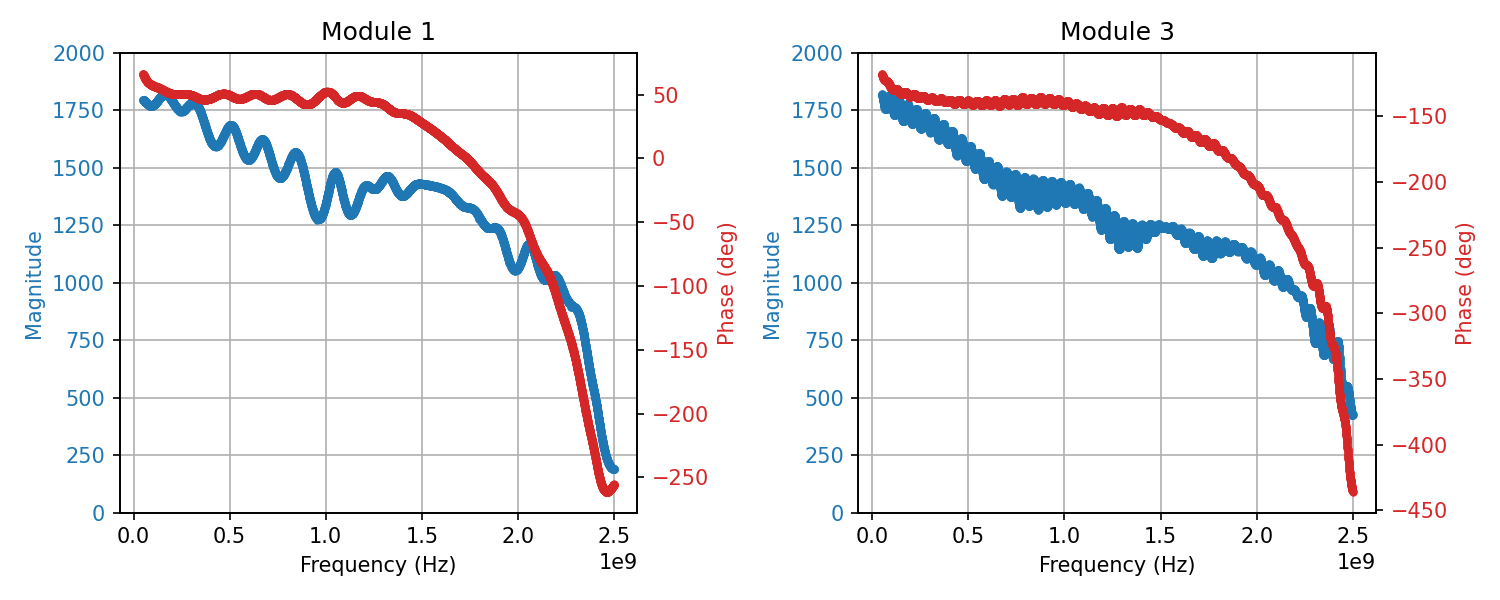


In the plots above, modules 1 and 3 are analog loopbacks with slightly different parameters.

* **Module 1:** ~30cm loopback cable with 2x VLFG-2000+ low-pass filters.
* **Module 3:** ~2m cable and 2x VLF-2250+ low-pass filters.

#### Example simplified network analysis code

The built-in function is best for efficient operation -- but the key measurement is shown below, such that the phase is reconstructed with no internal re-routing ("cal samples")

In [ ]:
crs.clear_channels()

fs = np.linspace(-249.234e6, 249.734e6, 1021)
await crs.set_nco_frequency(1.05e9, module=1)

mean_iq = []
mean_phase = []

for i in range(len(fs)):
    crs.set_frequency(fs[i], channel=i+1, module=1)
    crs.set_amplitude(0.001, channel=i+1, module=1)

samples = await crs.py_get_samples(100, channel=None, module=1)
sample_array = np.asarray(samples.i) + np.asarray(samples.q)*1.j

for ch in range(len(fs)):
    iq = np.mean(sample_array[ch])
    mean_iq.append(iq)
    mean_phase.append(np.degrees(np.arctan2(iq.imag, iq.real)))


fig, ax1 = plt.subplots(figsize=(6,4))

color_phase = 'tab:red'
ax1.set_xlabel("set_frequency (relative to NCO)")
ax1.set_ylabel("Phase (deg, arbitrary rotation)", color=color_phase)
ax1.plot(fs, mean_phase, color=color_phase, label="Phase")
ax1.tick_params(axis='y', labelcolor=color_phase)
ax1.grid(True)

ax2 = ax1.twinx()
color_mag = 'tab:blue'
ax2.set_ylabel("Magnitude", color=color_mag)
ax2.plot(fs, np.abs(mean_iq), color=color_mag, label="Magnitude")
ax2.tick_params(axis='y', labelcolor=color_mag)

ax1.set_title("Simplified netanal Measurement")

plt.tight_layout()
plt.show()


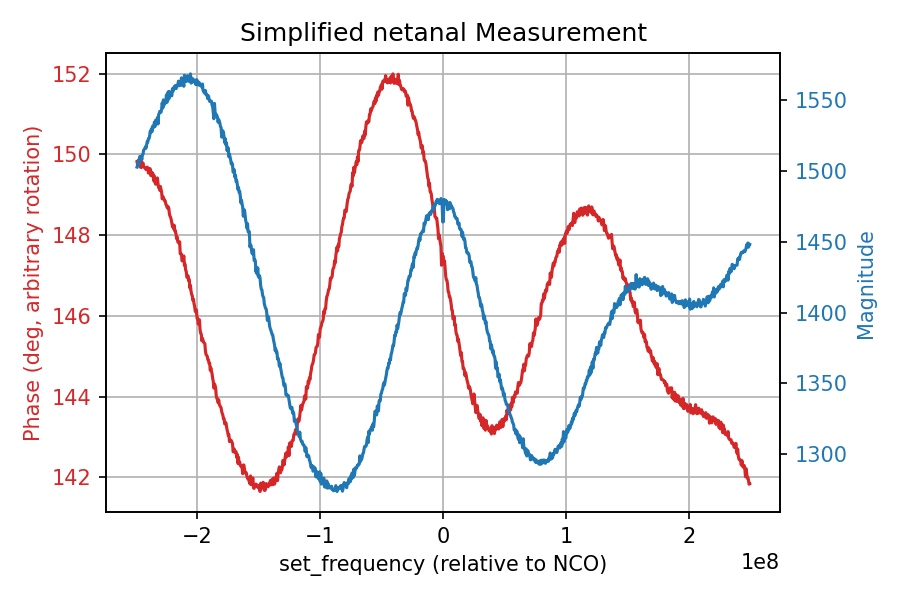


### 4. Extended module bandwidth is now off by default

At the extreme edges of the bandwidth we see attenuation, phase shifts, and are more susceptible to alias terms.
This is a natural consequence of the filtering presence that defines the NCO bandwidth.
Previously we left it up to users to determine the "usable" bandwidth. This caused confusion.

Now the default accessible bandwidth is fixed to 500MHz to ensure no aliasing products from outside the NCO, and no digital droops.
The full 625MHz is still accessible using:

The image below shows how the NCO bandwidth is defined through a series of digital filters:

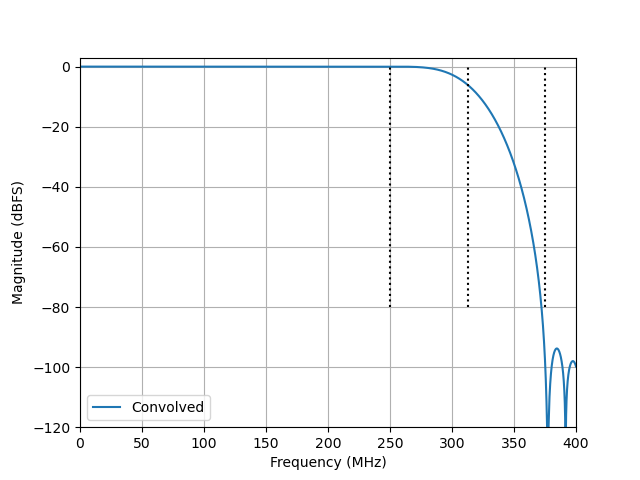

The three dotted lines are +/-250 MHz, +/-312.5 MHz, and 375 MHz.
Formally the "droop-free" region is the first dotted line, although we are able to sample out to the middle dotted line.

If you want to access the "extended" region between the first two dotted lines, you must now use this global configuration:
```python
crs.set_extended_module_bandwidth(True)
```


<div class="alert alert-block alert-warning"> The biggest issue with operating in the extended region isn't the uncompensated droop, digital phase shifts, or the frequency dependence within a readout band. Rather, it's contamination by aliasing. Tones in that transition will generate reflections across the 312.5MHz sampling frequency, which will alias into the data products without significant attenuation. This can result in confusing results for sensors where 10% aliasing power can be significant when interpretting detector performance results. It can also result in apparest stochasticity wherein detectors seem to require a differenet amount of bias power depending on where the NCO is relative to the detector frequency. Sticking to the non-extended bandwidth avoids these confusions. </div>